# Clustering Distrital con Grafos — VGAE Temporal

Se construye **un solo grafo temporal** con todos los años (2020–2025):
- **Nodos** = distrito × año (~11,334 nodos)
- **Aristas espaciales** = contigüidad Queen entre distritos del mismo año
- **Aristas temporales** = mismo distrito entre años consecutivos

Se entrena **un solo VGAE**. Al venir todos los embeddings del mismo espacio latente, los clusters son comparables entre años.

## 0. Dependencias

In [2]:
# !pip install torch-geometric libpysal umap-learn

In [3]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.impute import SimpleImputer

import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, VGAE
from torch_geometric.utils import from_scipy_sparse_matrix
import scipy.sparse as sp

import libpysal
import umap

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42)
print('Device:', DEVICE)

Device: cpu


## 1. Cargar datos

In [4]:
PANEL_PATH   = '../../data/clean/merged/panel_distrital_clean.csv'
GEOJSON_PATH = '../03_causal_model/cghciv.geojson'

panel = pd.read_csv(PANEL_PATH)
gdf   = gpd.read_file(GEOJSON_PATH)
gdf['UBIGEO'] = gdf['UBIGEO'].astype(str).str.zfill(6)
gdf_sorted    = gdf.sort_values('UBIGEO').reset_index(drop=True)
GEO_UBIGEOS   = gdf_sorted['UBIGEO'].tolist()

YEARS = sorted(panel['anio'].unique().tolist())
N_DISTRICTS = len(GEO_UBIGEOS)
N_YEARS     = len(YEARS)

print(f'Distritos: {N_DISTRICTS} | Años: {YEARS}')
print(f'Nodos totales en el grafo temporal: {N_DISTRICTS * N_YEARS}')

Distritos: 1889 | Años: [2020, 2021, 2022, 2023, 2024, 2025]
Nodos totales en el grafo temporal: 11334


## 2. Features de nodo

In [5]:
NODE_FEATURES = [
    'prevalencia_anemia',
    'gasto_total', 'gasto_anemia_pan',
    'personal_total', 'programa_anemia', 'centro_salud_municipal',
    'altitude', 'superficie', 'pob_densidad_2020',
    'pct_cultivo', 'pct_construido', 'pct_desnudo', 'pct_agua_visible',
    'n_edificios', 'densidad_edificios_km2',
    'elevacion_media', 'pendiente_media',
    'pct_agua_permanente', 'pct_agua_estacional',
]
print(f'Features: {len(NODE_FEATURES)}')

Features: 19


## 3. Construcción del grafo temporal

El nodo `i` en el año `t` tiene índice global `t * N_DISTRICTS + i`.

- **Aristas espaciales**: Queen contiguity dentro de cada año (replicadas 6 veces)
- **Aristas temporales**: mismo distrito entre años consecutivos

In [6]:
# --- Aristas espaciales (Queen) ---
w_queen = libpysal.weights.Queen.from_dataframe(gdf_sorted, silence_warnings=True)
sp_queen = w_queen.sparse  # (N_DISTRICTS × N_DISTRICTS)

spatial_edges = []
for t in range(N_YEARS):
    offset = t * N_DISTRICTS
    cx = sp_queen.tocoo()
    src = cx.row + offset
    dst = cx.col + offset
    spatial_edges.append(np.stack([src, dst]))

# --- Aristas temporales (mismo distrito, años consecutivos) ---
temporal_edges = []
for t in range(N_YEARS - 1):
    idx = np.arange(N_DISTRICTS)
    src = idx + t * N_DISTRICTS
    dst = idx + (t + 1) * N_DISTRICTS
    # bidireccional
    temporal_edges.append(np.stack([src, dst]))
    temporal_edges.append(np.stack([dst, src]))

all_edges = np.concatenate(spatial_edges + temporal_edges, axis=1)
EDGE_INDEX = torch.tensor(all_edges, dtype=torch.long)

print(f'Aristas espaciales : {sum(e.shape[1] for e in spatial_edges):,}')
print(f'Aristas temporales : {sum(e.shape[1] for e in temporal_edges):,}')
print(f'Total aristas      : {EDGE_INDEX.shape[1]:,}')

Aristas espaciales : 66,420
Aristas temporales : 18,890
Total aristas      : 85,310


## 4. Construcción de la matriz de features X

In [7]:
blocks = []
node_meta = []  # (ubigeo, anio) por cada nodo

for year in YEARS:
    df_yr = panel[panel['anio'] == year].copy()
    df_yr['ubigeo_str'] = df_yr['ubigeo'].astype(str).str.zfill(6)
    df_yr = df_yr.set_index('ubigeo_str').reindex(GEO_UBIGEOS)
    X = df_yr[NODE_FEATURES].values.astype(np.float32)
    blocks.append(X)
    node_meta.extend([(u, year) for u in GEO_UBIGEOS])

X_all = np.vstack(blocks)  # (N_DISTRICTS * N_YEARS, n_features)

# Imputar y normalizar globalmente
X_all = SimpleImputer(strategy='median').fit_transform(X_all)
X_all = StandardScaler().fit_transform(X_all)

x = torch.tensor(X_all, dtype=torch.float)
data = Data(x=x, edge_index=EDGE_INDEX)

node_meta_df = pd.DataFrame(node_meta, columns=['ubigeo', 'anio'])

print(f'X shape: {X_all.shape}')
print(f'Grafo: {data.num_nodes} nodos, {data.num_edges} aristas, {data.num_node_features} features')

X shape: (11334, 19)
Grafo: 11334 nodos, 85310 aristas, 19 features


## 5. Modelo VGAE

In [8]:
class VGAEEncoder(torch.nn.Module):
    def __init__(self, in_channels, hidden=128, out=64):
        super().__init__()
        self.conv_shared = GCNConv(in_channels, hidden)
        self.conv_mu     = GCNConv(hidden, out)
        self.conv_logstd = GCNConv(hidden, out)

    def forward(self, x, edge_index):
        h = F.relu(self.conv_shared(x, edge_index))
        return self.conv_mu(h, edge_index), self.conv_logstd(h, edge_index)

## 6. Entrenamiento

In [9]:
EPOCHS = 400
LR     = 1e-2

data  = data.to(DEVICE)
model = VGAE(VGAEEncoder(data.num_node_features)).to(DEVICE)
opt   = torch.optim.Adam(model.parameters(), lr=LR)

model.train()
for epoch in range(1, EPOCHS + 1):
    opt.zero_grad()
    z    = model.encode(data.x, data.edge_index)
    loss = model.recon_loss(z, data.edge_index) + (1 / data.num_nodes) * model.kl_loss()
    loss.backward()
    opt.step()
    if epoch % 100 == 0:
        print(f'epoch {epoch:4d} | loss {loss.item():.4f}')

model.eval()
with torch.no_grad():
    Z = model.encode(data.x, data.edge_index).cpu().numpy()

print(f'\nEmbeddings Z: {Z.shape}')

epoch  100 | loss 0.8487
epoch  200 | loss 0.8290
epoch  300 | loss 0.8187
epoch  400 | loss 0.8119

Embeddings Z: (11334, 64)


## 7. Clustering global

In [10]:
# Buscar k óptimo sobre todos los embeddings
sil_scores = {}
for k in range(3, 12):
    labels_k = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(Z)
    sil_scores[k] = silhouette_score(Z, labels_k)

best_k = max(sil_scores, key=sil_scores.get)
print('Silhouette por k:', {k: round(v, 3) for k, v in sil_scores.items()})
print(f'Mejor k: {best_k} (silhouette={sil_scores[best_k]:.3f})')

LABELS = KMeans(n_clusters=best_k, random_state=42, n_init=10).fit_predict(Z)
node_meta_df['cluster'] = LABELS

Silhouette por k: {3: 0.049, 4: 0.053, 5: 0.057, 6: 0.066, 7: 0.071, 8: 0.08, 9: 0.08, 10: 0.088, 11: 0.094}
Mejor k: 11 (silhouette=0.094)


## 8. Visualización: UMAP

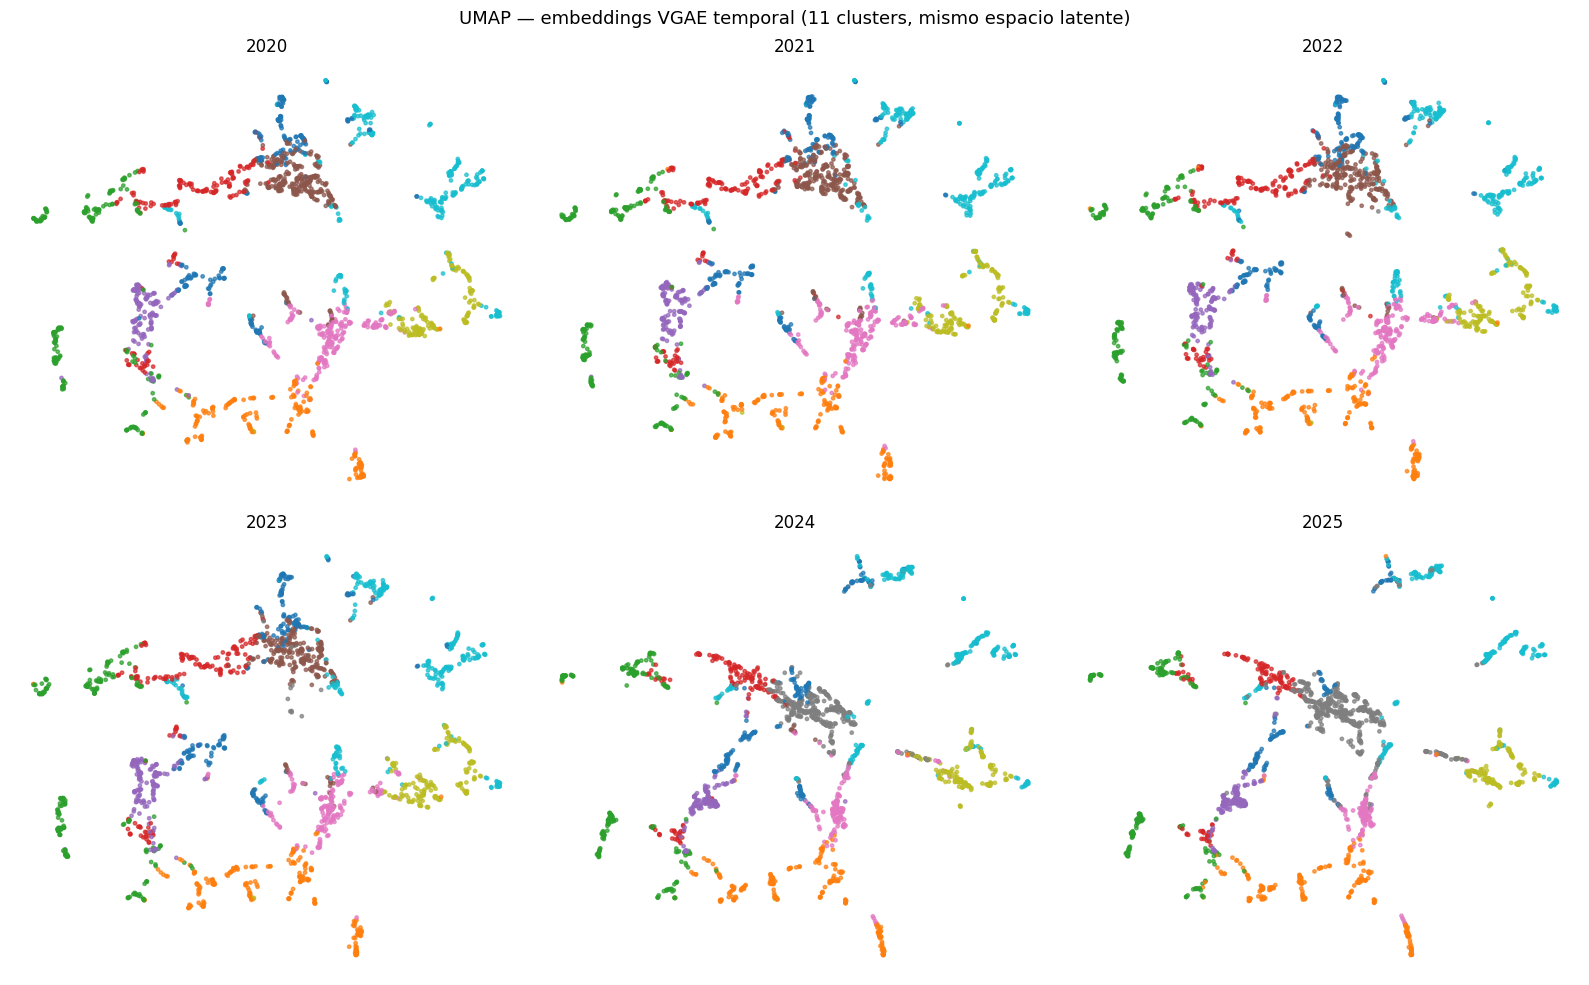

In [11]:
reducer = umap.UMAP(n_components=2, random_state=42)
Z2d = reducer.fit_transform(Z)
node_meta_df['umap_x'] = Z2d[:, 0]
node_meta_df['umap_y'] = Z2d[:, 1]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for i, year in enumerate(YEARS):
    mask = node_meta_df['anio'] == year
    sub  = node_meta_df[mask]
    axes.flatten()[i].scatter(
        sub['umap_x'], sub['umap_y'],
        c=sub['cluster'], cmap='tab10',
        vmin=0, vmax=best_k - 1,
        s=6, alpha=0.7
    )
    axes.flatten()[i].set_title(str(year))
    axes.flatten()[i].axis('off')

plt.suptitle(f'UMAP — embeddings VGAE temporal ({best_k} clusters, mismo espacio latente)', fontsize=13)
plt.tight_layout()
plt.savefig('fig_umap_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Visualización: mapas coropléticos (colores consistentes entre años)

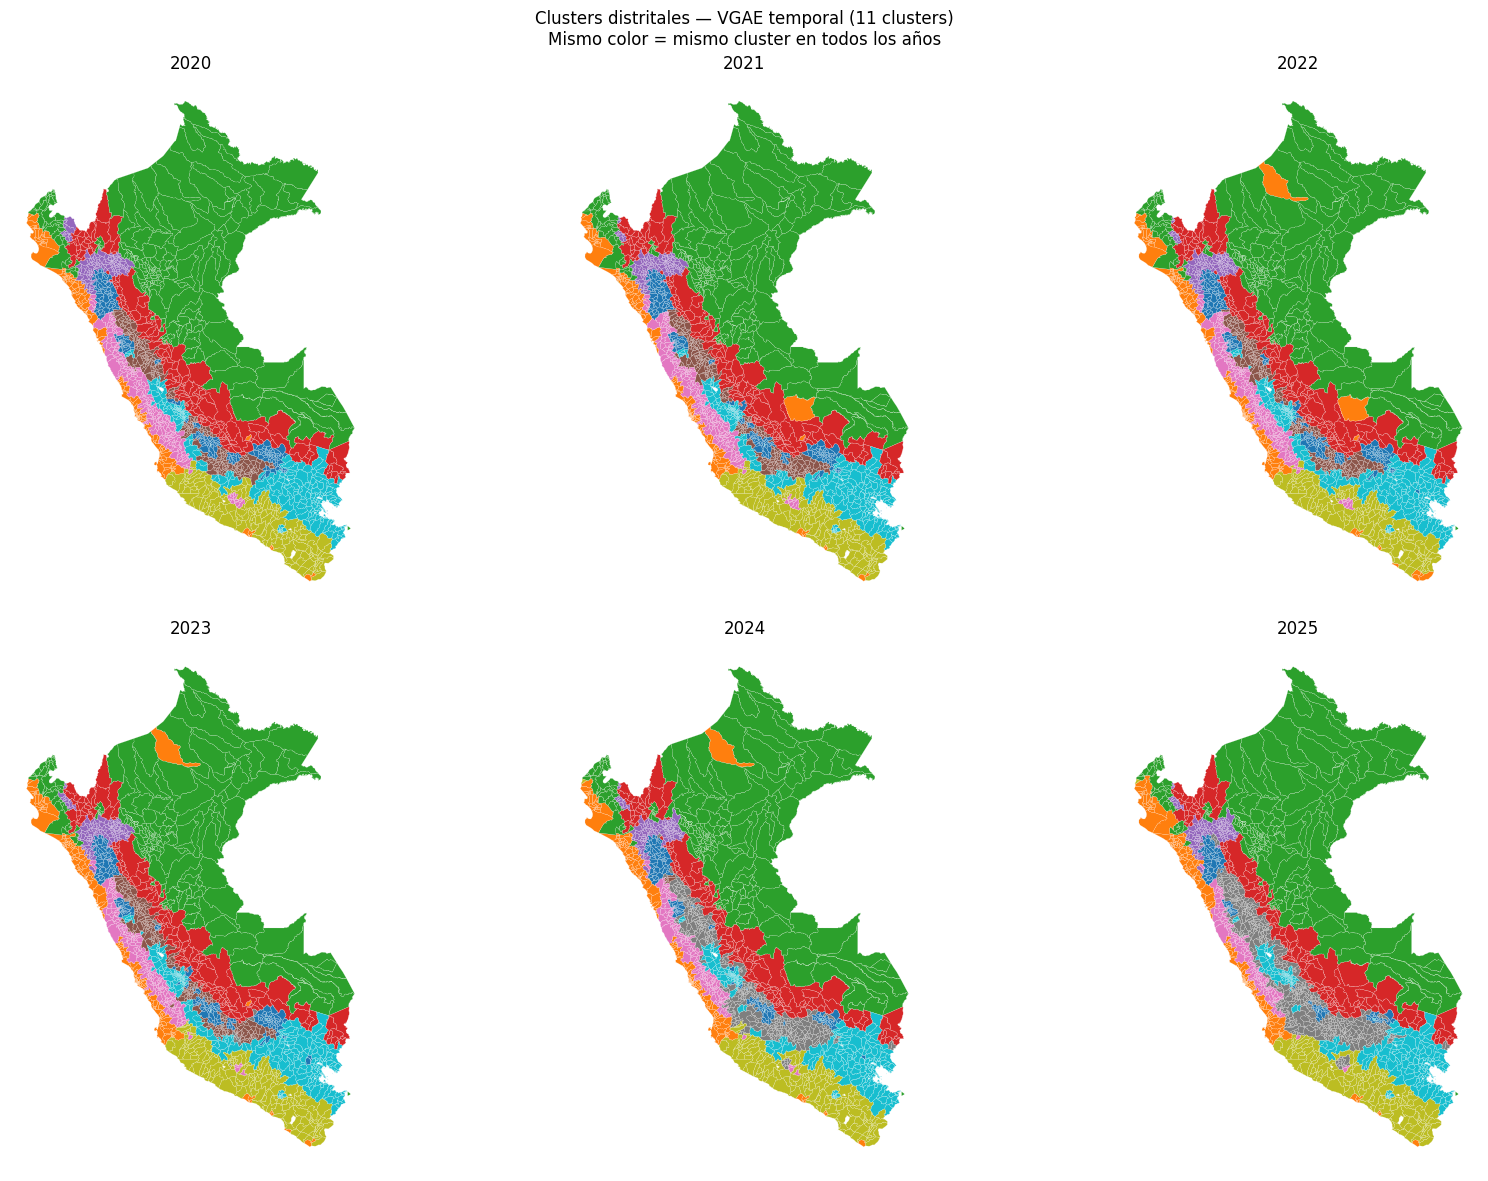

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

for i, year in enumerate(YEARS):
    mask     = node_meta_df['anio'] == year
    clusters = node_meta_df.loc[mask, 'cluster'].values

    gdf_plot = gdf_sorted.copy()
    gdf_plot['cluster'] = clusters
    gdf_plot.plot(
        column='cluster', ax=axes.flatten()[i],
        cmap='tab10', vmin=0, vmax=best_k - 1,
        linewidth=0.1, edgecolor='white'
    )
    axes.flatten()[i].set_title(str(year))
    axes.flatten()[i].axis('off')

plt.suptitle(f'Clusters distritales — VGAE temporal ({best_k} clusters)\nMismo color = mismo cluster en todos los años', fontsize=12)
plt.tight_layout()
plt.savefig('fig_map_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Perfil epidemiológico por cluster

In [13]:
df_full = panel.copy()
df_full['ubigeo_str'] = df_full['ubigeo'].astype(str).str.zfill(6)

df_full = df_full.merge(
    node_meta_df.rename(columns={'ubigeo': 'ubigeo_str'}),
    on=['ubigeo_str', 'anio'],
    how='left'
)

profile_cols = [
    'prevalencia_anemia', 'gasto_total', 'gasto_anemia_pan',
    'elevacion_media', 'pob_densidad_2020', 'pendiente_media',
]

profile = df_full.groupby('cluster')[profile_cols].mean().round(3)
profile['n_obs'] = df_full.groupby('cluster').size()
profile['macroregion_top'] = df_full.groupby('cluster')['macroregion_inei'].agg(
    lambda x: x.value_counts().index[0] if x.notna().any() else '?'
)

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
print(profile.to_string())

         prevalencia_anemia    gasto_total  gasto_anemia_pan  elevacion_media  pob_densidad_2020  pendiente_media  n_obs macroregion_top
cluster                                                                                                                                 
0                      0.33  62,110,812.62        446,841.36         3,439.67             116.87            20.37   1166          CENTRO
1                      0.16 747,386,165.66      1,458,047.26           304.09           3,870.43             8.31   1244           NORTE
2                      0.23  69,374,549.80        518,350.29           499.23              53.81             9.34   1266         ORIENTE
3                      0.33  45,532,088.98        278,838.80         2,209.38              23.62            25.10    946          CENTRO
4                      0.20  19,953,926.20        114,188.97         2,226.82              34.33            21.88    861           NORTE
5                      0.35  18,773,940.8

## 11. Exportar

In [14]:
out = node_meta_df[['ubigeo', 'anio', 'cluster']].copy()
out.to_csv('../../outputs/clusters_distritales.csv', index=False)
print('Guardado: outputs/clusters_distritales.csv')
out.head()

Guardado: outputs/clusters_distritales.csv


,ubigeo,anio,cluster
0,010101,2020,4
1,010102,2020,4
2,010103,2020,3
3,010104,2020,4
4,010105,2020,4


In [ ]:
import warnings; warnings.filterwarnings('ignore')
import json
import numpy as np
import pandas as pd
import geopandas as gpd
import ipywidgets as widgets
from IPython.display import display
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# --- Datos ---
clusters_df = pd.read_csv('../../outputs/clusters_distritales.csv')
clusters_df['ubigeo'] = clusters_df['ubigeo'].astype(str).str.zfill(6)

_panel = pd.read_csv('../../data/clean/merged/panel_distrital_clean.csv')
_panel['ubigeo_str'] = _panel['ubigeo'].astype(str).str.zfill(6)

_gdf = gpd.read_file('../03_causal_model/cghciv.geojson')
_gdf['UBIGEO'] = _gdf['UBIGEO'].astype(str).str.zfill(6)
_gdf = _gdf.sort_values('UBIGEO').reset_index(drop=True).to_crs(epsg=4326)
_geojson = json.loads(_gdf.to_json())
_ubigeos = _gdf['UBIGEO'].tolist()

df_viz = _panel.merge(clusters_df, left_on=['ubigeo_str', 'anio'], right_on=['ubigeo', 'anio'], how='left')
_YEARS = sorted(df_viz['anio'].unique())
N_CLUSTERS = int(df_viz['cluster'].nunique())

FEATURE_LABELS = {
    'prevalencia_anemia' : 'Prevalencia anemia',
    'gasto_total'        : 'Gasto total',
    'gasto_anemia_pan'   : 'Gasto anemia/PAN',
    'personal_total'     : 'Personal total',
    'elevacion_media'    : 'Elevacion media',
    'pob_densidad_2020'  : 'Densidad pob.',
    'pendiente_media'    : 'Pendiente media',
    'pct_construido'     : '% construido',
    'pct_cultivo'        : '% cultivo',
    'n_edificios'        : 'N edificios',
}
FEAT_KEYS = list(FEATURE_LABELS.keys())
global_means = df_viz[FEAT_KEYS].mean()
global_stds  = df_viz[FEAT_KEYS].std().replace(0, 1)
all_yr_global = df_viz.groupby('anio')['prevalencia_anemia'].mean().reindex(_YEARS).values

def get_map_z(sel):
    out = []
    for year in _YEARS:
        yr = df_viz[df_viz['anio'] == year][['ubigeo_str','cluster']].drop_duplicates()
        yr = yr.set_index('ubigeo_str').reindex(_ubigeos)
        out.append((yr['cluster'] == sel).astype(float).fillna(0).values)
    return out

def get_line_y(sel):
    return df_viz[df_viz['cluster'] == sel].groupby('anio')['prevalencia_anemia'].mean().reindex(_YEARS).values

def get_feat_z(sel):
    cl_means = df_viz[df_viz['cluster'] == sel][FEAT_KEYS].mean()
    return ((cl_means - global_means) / global_stds).values

# ── Inicializar figuras con cluster 0 ────────────────────────────

# Mapa
_map_fig = make_subplots(
    rows=2, cols=3,
    subplot_titles=[str(y) for y in _YEARS],
    specs=[[{'type': 'choropleth'}] * 3] * 2,
    vertical_spacing=0.05, horizontal_spacing=0.02,
)
for i, (year, zvals) in enumerate(zip(_YEARS, get_map_z(0))):
    _map_fig.add_trace(go.Choropleth(
        geojson=_geojson, locations=_ubigeos, z=zvals,
        featureidkey='properties.UBIGEO',
        colorscale=[[0, '#e0e0e0'], [1, '#e63946']],
        zmin=0, zmax=1, showscale=False,
        marker_line_width=0.1, marker_line_color='white',
    ), row=i // 3 + 1, col=i % 3 + 1)
_map_fig.update_geos(fitbounds='locations', visible=False)
_map_fig.update_layout(height=480, margin=dict(t=40, b=0, l=0, r=0),
    title_text='<b>Cluster 0</b> — distribucion geografica por año')
fw_map = go.FigureWidget(_map_fig)

# Línea temporal
_y0 = get_line_y(0)
fw_line = go.FigureWidget([
    go.Scatter(x=_YEARS, y=_y0, name='Cluster 0',
               line=dict(color='#e63946', width=3), mode='lines+markers', marker_size=8),
    go.Scatter(x=_YEARS, y=all_yr_global, name='Promedio global',
               line=dict(color='#aaa', width=2, dash='dash'), mode='lines+markers', marker_size=6),
])
fw_line.update_layout(height=280, yaxis=dict(tickformat='.1%'),
    title='<b>Prevalencia anemia — Cluster 0 vs promedio global</b>',
    margin=dict(t=40, b=40, l=60, r=20), legend=dict(orientation='h', y=1.15))

# Perfil features
_z0 = get_feat_z(0)
fw_feat = go.FigureWidget([go.Bar(
    x=_z0, y=list(FEATURE_LABELS.values()), orientation='h',
    marker_color=['#e63946' if v >= 0 else '#457b9d' for v in _z0],
    text=[f'{v:+.2f}' for v in _z0], textposition='outside',
)])
fw_feat.add_vline(x=0, line_color='black', line_width=1)
fw_feat.update_layout(height=360,
    title='<b>Perfil Cluster 0</b> — z-score vs media global',
    xaxis_title='Desviaciones estandar sobre/bajo la media',
    margin=dict(t=40, b=40, l=140, r=80),
    xaxis=dict(range=[_z0.min() - 0.5, _z0.max() + 0.8]))

# ── Dropdown ─────────────────────────────────────────────────────
dropdown = widgets.Dropdown(
    options=[(f'Cluster {k}', k) for k in range(N_CLUSTERS)],
    value=0, description='Cluster:',
    layout=widgets.Layout(width='220px'),
    style={'description_width': 'initial'},
)

def on_change(change):
    sel = dropdown.value

    with fw_map.batch_update():
        for i, zvals in enumerate(get_map_z(sel)):
            fw_map.data[i].z = zvals
        fw_map.layout.title.text = f'<b>Cluster {sel}</b> — distribucion geografica por año'

    yl = get_line_y(sel)
    with fw_line.batch_update():
        fw_line.data[0].y = yl
        fw_line.data[0].name = f'Cluster {sel}'
        fw_line.layout.title.text = f'<b>Prevalencia anemia — Cluster {sel} vs promedio global</b>'

    zf = get_feat_z(sel)
    with fw_feat.batch_update():
        fw_feat.data[0].x = zf
        fw_feat.data[0].marker.color = ['#e63946' if v >= 0 else '#457b9d' for v in zf]
        fw_feat.data[0].text = [f'{v:+.2f}' for v in zf]
        fw_feat.layout.title.text = f'<b>Perfil Cluster {sel}</b> — z-score vs media global'
        fw_feat.layout.xaxis.range = [zf.min() - 0.5, zf.max() + 0.8]

dropdown.observe(on_change, names='value')
display(widgets.VBox([dropdown, fw_map, fw_line, fw_feat]))

## 12. Explorador interactivo de clusters\n\nSeleccioná un cluster con el dropdown para ver:\n- **Mapa**: distribución geográfica en cada año (rojo = cluster seleccionado)\n- **Evolución**: prevalencia de anemia del cluster vs promedio global a lo largo del tiempo\n- **Perfil**: z-score de cada feature vs la media global (rojo = sobre la media, azul = bajo la media)

In [ ]:
gdf23.plot(column='prevalencia_anemia', ax=ax, cmap='RdYlGn_r', linewidth=0.05,
           edgecolor='white', legend=True,
           legend_kwds={'label':'Prevalencia anemia','shrink':0.5,
                        'orientation':'horizontal','pad':0.01})
cb = ax.get_figure().axes[-1]
cb.set_xticklabels([f'{float(t.get_text()):.0%}' for t in cb.get_xticklabels()])

In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# HALLAZGO — "La brecha es estructural: 6 años sin cerrarse"
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
YEARS = sorted(_df['anio'].unique())

# Clusters crítico (6) y mejor (1) según perfil previo
C_CRIT  = 6   # mayor prevalencia
C_MEJOR = 1   # menor prevalencia

ts_crit  = _df[_df['cluster'] == C_CRIT ].groupby('anio')['prevalencia_anemia'].mean()
ts_mejor = _df[_df['cluster'] == C_MEJOR].groupby('anio')['prevalencia_anemia'].mean()
ts_glob  = _df.groupby('anio')['prevalencia_anemia'].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='white',
                         gridspec_kw={'width_ratios': [1.6, 1]})

# ── Panel izquierdo: evolución temporal ──────────────────
ax = axes[0]
ax.plot(YEARS, ts_glob .reindex(YEARS), color=GRAY,  linewidth=2,
        linestyle='--', label='Promedio nacional', zorder=2)
ax.plot(YEARS, ts_crit .reindex(YEARS), color=RED,   linewidth=3,
        marker='o', markersize=7, label=f'Cluster crítico ({C_CRIT})', zorder=3)
ax.plot(YEARS, ts_mejor.reindex(YEARS), color=BLUE,  linewidth=3,
        marker='o', markersize=7, label=f'Cluster mejor ({C_MEJOR})', zorder=3)

# Brecha anotada en el último año
yr_last = YEARS[-1]
y_crit  = ts_crit[yr_last]
y_mejor = ts_mejor[yr_last]
ax.annotate('', xy=(yr_last + 0.05, y_mejor),
            xytext=(yr_last + 0.05, y_crit),
            arrowprops=dict(arrowstyle='<->', color='#555', lw=1.5))
ax.text(yr_last + 0.1, (y_crit + y_mejor) / 2,
        f'{y_crit - y_mejor:.0%}\nde brecha',
        fontsize=9, va='center', color='#333')

# Etiquetas directas al final de línea
ax.text(yr_last + 0.15, y_crit  + 0.005, f'Cluster {C_CRIT}',
        fontsize=9, color=RED, fontweight='bold', va='bottom')
ax.text(yr_last + 0.15, y_mejor - 0.005, f'Cluster {C_MEJOR}',
        fontsize=9, color=BLUE, fontweight='bold', va='top')

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.set_xlim(YEARS[0] - 0.3, YEARS[-1] + 1)
ax.set_xlabel('Año', fontsize=11)
ax.set_ylabel('Prevalencia de anemia', fontsize=11)
ax.set_title('La brecha entre el cluster crítico y\nel mejor nunca se cerró en 6 años',
             fontsize=12, fontweight='bold', loc='left', pad=10)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')

# ── Panel derecho: perfil comparativo ────────────────────
ax2 = axes[1]
metrics = {
    'Prevalencia\nanemia'  : ('prevalencia_anemia', 1),
    'Gasto total\n(M PEN)' : ('gasto_total',        1e6),
    'Elevacion\n(m)'       : ('elevacion_media',     1),
}
labels, vals_crit, vals_mejor = [], [], []
for lbl, (col, scale) in metrics.items():
    labels.append(lbl)
    vals_crit .append(_df[_df['cluster'] == C_CRIT ][col].mean() / scale)
    vals_mejor.append(_df[_df['cluster'] == C_MEJOR][col].mean() / scale)

x = np.arange(len(labels))
w = 0.32
b1 = ax2.bar(x - w/2, vals_crit,  w, color=RED,  label=f'Cluster {C_CRIT}',  zorder=3)
b2 = ax2.bar(x + w/2, vals_mejor, w, color=BLUE, label=f'Cluster {C_MEJOR}', zorder=3)

ax2.bar_label(b1, fmt='%.2f', fontsize=8, padding=2, color=RED)
ax2.bar_label(b2, fmt='%.2f', fontsize=8, padding=2, color=BLUE)
ax2.set_xticks(x)
ax2.set_xticklabels(labels, fontsize=9)
ax2.set_title('Perfil promedio\n2020–2025', fontsize=12, fontweight='bold',
              loc='left', pad=10)
ax2.spines['left'].set_color('#cccccc')
ax2.spines['bottom'].set_color('#cccccc')
ax2.set_yticks([])
ax2.legend(frameon=False, fontsize=9, loc='upper right')

fig.text(0.5, -0.02,
         'Fuente: SIEN-REUNIS + SIAF 2020-2025 | Modelo: VGAE temporal con contigüidad Queen',
         ha='center', fontsize=8, color='#888888')

plt.tight_layout()
plt.savefig('fig_story_05_hallazgo.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# RESOLUCIÓN — "El grafo une lo que la tabla separa"
# Subgrafo ego alrededor de Cusco (código 080101) mostrando
# aristas espaciales y temporales
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# Construir grafo Queen solo con los índices del GDF
w_q = libpysal.weights.Queen.from_dataframe(_gdf, silence_warnings=True)

# Ego-grafo: Cusco + sus vecinos (índice en el GDF)
center_idx = _gdf[_gdf['UBIGEO'] == '080101'].index
if len(center_idx) == 0:
    center_idx = [500]   # fallback
else:
    center_idx = [center_idx[0]]

ego_nodes = set(center_idx)
for n in center_idx:
    ego_nodes.update(w_q.neighbors[n])
ego_nodes = list(ego_nodes)[:12]  # limitar para legibilidad

# Grafo NetworkX — año t y año t+1
G = nx.Graph()
YEAR_COLORS = {0: BLUE, 1: '#a8dadc'}

for t in range(2):
    for n in ego_nodes:
        G.add_node((n, t), year=t)

# Aristas espaciales (mismo año)
for t in range(2):
    for n in ego_nodes:
        for nb in w_q.neighbors[n]:
            if nb in ego_nodes:
                G.add_edge((n, t), (nb, t), tipo='espacial')

# Aristas temporales (mismo distrito, años consecutivos)
for n in ego_nodes:
    G.add_edge((n, 0), (n, 1), tipo='temporal')

# Layout: separar los dos años verticalmente
pos = {}
gdf_sub = _gdf.loc[ego_nodes].copy()
gdf_sub = gdf_sub.to_crs(epsg=32718)   # proyección métrica
cx = gdf_sub.geometry.centroid.x.values
cy = gdf_sub.geometry.centroid.y.values
cx = (cx - cx.mean()) / cx.std()
cy = (cy - cy.mean()) / cy.std()

for i, n in enumerate(ego_nodes):
    pos[(n, 0)] = (cx[i], cy[i] + 0.3)
    pos[(n, 1)] = (cx[i], cy[i] - 0.3)

fig, ax = plt.subplots(figsize=(10, 7), facecolor='white')
ax.set_facecolor('white')

# Aristas espaciales
sp_edges = [(u, v) for u, v, d in G.edges(data=True) if d['tipo'] == 'espacial']
nx.draw_networkx_edges(G, pos, edgelist=sp_edges,
                       edge_color=BLUE, alpha=0.5, width=1.5, ax=ax)

# Aristas temporales
tm_edges = [(u, v) for u, v, d in G.edges(data=True) if d['tipo'] == 'temporal']
nx.draw_networkx_edges(G, pos, edgelist=tm_edges,
                       edge_color='#f4a261', alpha=0.9, width=2,
                       style='dashed', ax=ax)

# Nodos
for t, label, color in [(0, 'Año t', BLUE), (1, 'Año t+1', '#a8dadc')]:
    nodes_t = [n for n in G.nodes if n[1] == t]
    sizes   = [350 if n[0] == center_idx[0] else 180 for n in nodes_t]
    nx.draw_networkx_nodes(G, pos, nodelist=nodes_t,
                           node_color=color, node_size=sizes,
                           edgecolors=DARK, linewidths=0.8, ax=ax)

# Etiqueta nodo central
cx_c, cy_c = pos[(center_idx[0], 0)]
ax.text(cx_c, cy_c + 0.08, 'Cusco', fontsize=9,
        ha='center', fontweight='bold', color=DARK)

# Etiquetas de año
ax.text(-2.8,  0.4, 'Año t',   fontsize=11, color=BLUE,      fontweight='bold')
ax.text(-2.8, -0.4, 'Año t+1', fontsize=11, color='#457b9d', fontweight='bold')

# Leyenda
legend_elements = [
    Line2D([0], [0], color=BLUE,     linewidth=2,   label='Arista espacial (vecinos Queen)'),
    Line2D([0], [0], color='#f4a261', linewidth=2,
           linestyle='dashed',        label='Arista temporal (mismo distrito)'),
]
ax.legend(handles=legend_elements, loc='lower right', frameon=False, fontsize=10)

ax.set_title(
    'El grafo conecta cada distrito con sus vecinos físicos\n'
    'y consigo mismo en el tiempo — el modelo aprende de ambos',
    fontsize=13, fontweight='bold', pad=14, loc='left'
)
ax.set_axis_off()

plt.tight_layout()
plt.savefig('fig_story_04_grafo.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# COMPLICACIÓN 2 — "K-Means cambia de opinión cada año"
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
FEATS = ['prevalencia_anemia','gasto_total','altitude','pob_densidad_2020',
         'elevacion_media','pendiente_media','pct_construido','pct_cultivo']

def raw_kmeans(year, k=6, seed=0):
    df_y = _panel[_panel['anio'] == year].copy()
    df_y['ubigeo_str'] = df_y['ubigeo'].astype(str).str.zfill(6)
    df_y = df_y.set_index('ubigeo_str').reindex(_gdf['UBIGEO'])
    X = SimpleImputer(strategy='median').fit_transform(df_y[FEATS].values)
    X = StandardScaler().fit_transform(X)
    return KMeans(n_clusters=k, random_state=seed, n_init=10).fit_predict(X)

l2020 = raw_kmeans(2020, seed=0)
l2021 = raw_kmeans(2021, seed=0)

gdf_km = _gdf.copy()
gdf_km['c2020'] = l2020
gdf_km['c2021'] = l2021

fig, axes = plt.subplots(1, 2, figsize=(13, 8), facecolor='white')

for ax, col, year in zip(axes, ['c2020','c2021'], [2020, 2021]):
    gdf_km.plot(column=col, ax=ax, cmap='tab10', vmin=0, vmax=5,
                linewidth=0.08, edgecolor='white')
    ax.set_axis_off()
    ax.set_title(str(year), fontsize=14, fontweight='bold', pad=6)

# Flechas apuntando a la misma zona geográfica con diferente color
for ax in axes:
    ax.annotate('', xy=(-74.5, -14), xytext=(-71.5, -12.8),
                arrowprops=dict(arrowstyle='->', color=RED, lw=2))

axes[0].text(-71.2, -12.6, 'Zona\nreferencia', fontsize=9, color=RED, fontweight='bold')

fig.suptitle(
    'K-Means reasigna colores arbitrariamente cada año\n'
    '— comparar 2020 con 2021 no tiene sentido',
    fontsize=13, fontweight='bold', y=0.97
)
fig.text(0.5, 0.01, 'Mismo algoritmo, mismos parámetros, misma zona → distinto color',
         ha='center', fontsize=10, color=RED,
         bbox=dict(facecolor='#fff0f0', edgecolor=RED, boxstyle='round,pad=0.4'))

plt.tight_layout(rect=[0, 0.04, 1, 0.95])
plt.savefig('fig_story_03_label_switching.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# COMPLICACIÓN 1 — "Un distrito no existe en el vacío: sus vecinos lo explican"
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
w = libpysal.weights.Queen.from_dataframe(_gdf, silence_warnings=True)
w.transform = 'r'  # row-standardize

prev23 = (df23.set_index('ubigeo_str')
              .reindex(_gdf['UBIGEO'])['prevalencia_anemia']
              .fillna(df23['prevalencia_anemia'].median())
              .values)

lag23 = libpysal.weights.lag_spatial(w, prev23)  # promedio vecinos

# Moran's I manual
n   = len(prev23)
xc  = prev23 - prev23.mean()
lxc = lag23  - lag23.mean()
moran_i = (xc * lxc).sum() / (xc ** 2).sum()

fig, ax = plt.subplots(figsize=(7, 6), facecolor='white')

ax.scatter(prev23, lag23, alpha=0.25, s=12, color=GRAY, zorder=2)

# Tendencia
m, b = np.polyfit(prev23, lag23, 1)
xs = np.linspace(prev23.min(), prev23.max(), 100)
ax.plot(xs, m * xs + b, color=RED, linewidth=2.5, zorder=3)

# Cuadrantes
pm, lm = prev23.mean(), lag23.mean()
ax.axvline(pm, color='#bbbbbb', linewidth=0.8, linestyle='--')
ax.axhline(lm, color='#bbbbbb', linewidth=0.8, linestyle='--')

# Anotación del Moran's I
ax.text(0.97, 0.05,
        f"Índice de Moran = {moran_i:.2f}\n(1 = perfecta autocorrelación espacial)",
        transform=ax.transAxes, ha='right', va='bottom',
        fontsize=10, color=DARK,
        bbox=dict(facecolor='white', edgecolor=GRAY, boxstyle='round,pad=0.4'))

ax.set_xlabel('Prevalencia del distrito', fontsize=11)
ax.set_ylabel('Prevalencia promedio\nde sus vecinos', fontsize=11)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

ax.set_title(
    'Un distrito con alta anemia está rodeado de vecinos\ncon alta anemia — no son observaciones independientes',
    fontsize=13, fontweight='bold', pad=12, loc='left'
)
ax.text(0, -0.1, 'Fuente: SIEN-REUNIS 2023 | Contigüidad Queen',
        transform=ax.transAxes, fontsize=8, color='#888888')

plt.tight_layout()
plt.savefig('fig_story_02_autocorrelacion.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# SITUACIÓN — "La anemia no se distribuye al azar en el territorio"
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
df23  = _panel[_panel['anio'] == 2023][['ubigeo_str','prevalencia_anemia']].copy()
gdf23 = _gdf.merge(df23, left_on='UBIGEO', right_on='ubigeo_str', how='left')

fig, ax = plt.subplots(figsize=(7, 9), facecolor='white')

gdf23.plot(
    column='prevalencia_anemia', ax=ax,
    cmap='Reds',
    missing_kwds={'color': '#eeeeee'},
    linewidth=0.05, edgecolor='white',
    legend=True,
    legend_kwds={'label': 'Prevalencia de anemia', 'shrink': 0.5,
                 'orientation': 'horizontal', 'pad': 0.01}
)

# Formatear ticks del colorbar como %
cb = ax.get_figure().axes[-1]
ticks = cb.get_xticks()
cb.set_xticklabels([f'{t:.0%}' for t in ticks])

# Anotaciones directas — mismo color oscuro, diferente intensidad de flecha
ax.annotate('Hasta 80%\nen sierra', xy=(-74.5, -13.5), fontsize=9,
            color=RED, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=RED, lw=1.5),
            xytext=(-71, -12.5))
ax.annotate('Bajo 15%\nen costa norte', xy=(-80.5, -5), fontsize=9,
            color='#888888', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#888888', lw=1.2),
            xytext=(-76, -3.5))

ax.set_title(
    'La anemia se concentra en la sierra y\nes casi inexistente en la costa norte',
    fontsize=13, fontweight='bold', pad=12, loc='left'
)
ax.set_axis_off()
ax.text(0, -0.03, 'Fuente: SIEN-REUNIS 2023 | n = 1,891 distritos',
        transform=ax.transAxes, fontsize=8, color='#888888')

plt.tight_layout()
plt.savefig('fig_story_01_situacion.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
import networkx as nx
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import libpysal

# ── Estilo Evergreen ──────────────────────────────────────────────
plt.rcParams.update({
    'font.family'        : 'sans-serif',
    'font.size'          : 11,
    'axes.spines.top'    : False,
    'axes.spines.right'  : False,
    'axes.spines.left'   : True,
    'axes.spines.bottom' : True,
    'axes.grid'          : False,
    'figure.facecolor'   : 'white',
    'axes.facecolor'     : 'white',
    'axes.labelcolor'    : '#333333',
    'text.color'         : '#333333',
    'xtick.color'        : '#555555',
    'ytick.color'        : '#555555',
})

GRAY   = '#cccccc'
RED    = '#e63946'
BLUE   = '#457b9d'
DARK   = '#1d3557'

# ── Datos comunes ─────────────────────────────────────────────────
_panel = pd.read_csv('../../data/clean/merged/panel_distrital_clean.csv')
_panel['ubigeo_str'] = _panel['ubigeo'].astype(str).str.zfill(6)

_clusters = pd.read_csv('../../outputs/clusters_distritales.csv')
_clusters['ubigeo'] = _clusters['ubigeo'].astype(str).str.zfill(6)

_gdf = gpd.read_file('../03_causal_model/cghciv.geojson')
_gdf['UBIGEO'] = _gdf['UBIGEO'].astype(str).str.zfill(6)
_gdf = _gdf.sort_values('UBIGEO').reset_index(drop=True)

_df = _panel.merge(_clusters, left_on=['ubigeo_str','anio'], right_on=['ubigeo','anio'], how='left')

print("Datos cargados OK")
print(f"  Panel: {_panel.shape} | Clusters: {_clusters.shape}")

---\n## 13. Storytelling — Graph Clustering para Equipo Técnico\n\n> Estructura SCR (Stephanie Evergreen): **Situación → Complicación → Resolución → Hallazgo**\n>\n> Principios aplicados: título = insight, una sola idea por gráfico, color con propósito, anotaciones directas, sin chartjunk.